In [1]:
import sys
import os
import pandas as pd

sys.path.append('../src/scripts')
sys.path.append('../src/classes')
from simulation import Simulation
from config import get_simulation_number
from data_scraping_in_results import scraper

In [2]:
mobility_file_path = '../src/sumo/csv/train_single.csv'
edge_file_path = '../src/inputs/train/edge_servers.json'
vehicle_file_path = '../src/inputs/train/vehicles_single.json'


In [3]:
_proposed="proposed"
_local= "local_only"
_offload = "offload_only"
_random = "random"
algorithms = [_proposed,_local,_offload,_random]
simulation_number = 37
report_paths = {}

for a in algorithms:
    report_paths[a] = ('../results/reports/'+str(simulation_number)+'_report_'+a+'_test.csv')
q_table_path = '../results/q_table/'+str(simulation_number)+'_q_table_proposed'

#overwrite specific report addresses for proposed
proposed_test_sim_number=45
proposed_test_number=2
report_paths[_proposed]='../results/reports/'+str(proposed_test_sim_number)+'_report_'+_proposed+'_test_'+str(proposed_test_number)+'.csv'


num_of_cars=20
end_time_limit=-1
# should_update_q_table = False
print(report_paths)

{'proposed': '../results/reports/45_report_proposed_test_2.csv', 'local_only': '../results/reports/37_report_local_only_test.csv', 'offload_only': '../results/reports/37_report_offload_only_test.csv', 'random': '../results/reports/37_report_random_test.csv'}


In [4]:
scrapers={}
for a in algorithms:
    scrapers[a] = scraper(report_paths[a],num_of_cars,end_time_limit)

---------------------------------------------
../results/reports/45_report_proposed_test_2.csv
No time limit
Header --->
   vehicle_id  task_id  execution_location      size    distance  \
0           1        1                   0  10000000  193.826094   
1           1        2                   0   5000000  193.816105   
2           1        4                   0   8000000  193.716216   
3           1        5                   0  10000000  193.625845   
4           1        6                   0   3000000  193.515967   

   transfer_rate  execution_cycles  start_time  end_time  release_time  \
0            0.0        5000000000           1      5001             1   
1            0.0        6000000000        5001     11001           101   
2            0.0        7000000000       11001     18001           301   
3            0.0        5000000000       18001     23001           401   
4            0.0        4000000000       23001     27001           501   

   response_time  transmi

In [5]:
averages = {}
for a in algorithms:
    print("=========================================")
    print(a,"------->")
    averages[a] = scrapers[a].calc_average_all(False)

final_df = pd.concat(averages, names=['Algorithm'])
print(final_df)



proposed ------->
local_only ------->
offload_only ------->
random ------->
Algorithm                  
proposed      response_time    458896.198412
              total_energy          1.080630
local_only    response_time    489599.940030
              total_energy          0.597331
offload_only  response_time    468509.392210
              total_energy          1.024538
random        response_time    457156.282128
              total_energy          0.924714
dtype: float64


In [6]:
for a in algorithms:
    print("=========================================")
    print(a,"----------AVERAGED----->")
    scrapers[a].calc_average_for_each_car()

proposed ----------AVERAGED----->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1           449837.182898        2344.610451     3068.408551   
2           584390.357330        3584.938482     2210.994764   
3           535210.988679        3626.583019     2756.603774   
4           347454.921101        1858.049541     2625.688073   
5           505847.885135        1640.355856     2944.144144   
6           361831.276618        1888.060543     2020.876827   
7           419196.662000        5328.882000     2817.200000   
8           525843.520767        1286.859425     3730.351438   
9           556520.906593        3082.760989     2249.450549   
10          508887.470699        2464.742911     2667.674858   
11          478403.104623        2011.459854     3122.627737   
12          323532.082397        1401.664794     2692.509363   
13          556069.748905        2726.583942     2361.751825   
14    

In [7]:
for a in algorithms:
    print("=========================================")
    print(a,"----TOTAL------->")
    scrapers[a].calc_sum_for_each_car()

proposed ----TOTAL------->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1               189381454             987081         1291800   
2               446474233            2738893         1689200   
3               283661824            1922089         1461000   
4               189362932            1012637         1431000   
5               224596461             728318         1307200   
6               346634363            1808762         1936000   
7               209598331            2664441         1408600   
8               164589022             402787         1167600   
9               405147220            2244250         1637600   
10              269201472            1303849         1411200   
11              196623676             826710         1283400   
12              172766132             748489         1437800   
13              380907778            1867710         1617800   
14           

proposed -------AVERAGE----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1328             1327.0              127.0          1200.0               0.0   
1599             1598.0              798.0           800.0               0.0   
1728             1627.0               28.0           400.0               0.0   
1952             1951.0              551.0          1400.0               0.0   
2101             2000.0                0.0          2000.0               0.2   
...                 ...                ...             ...               ...   
999352         943151.0            15399.0          1200.0               0.0   
999728         956727.0             4573.0          2000.0               0.0   
999749         697348.0              910.0          1800.0               0.0   
999757         909156.0             2080.0          2000.0               0.0   
999813    

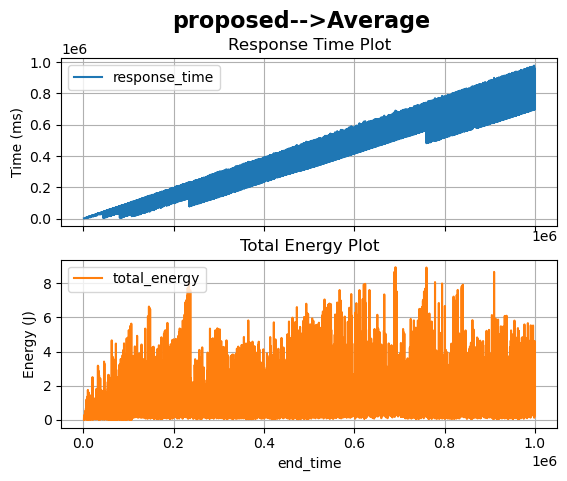

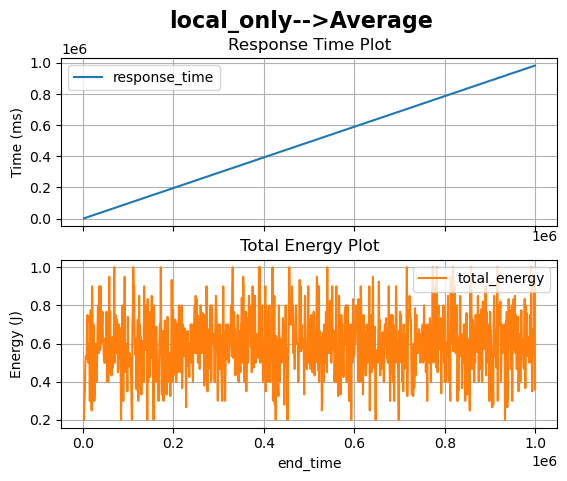

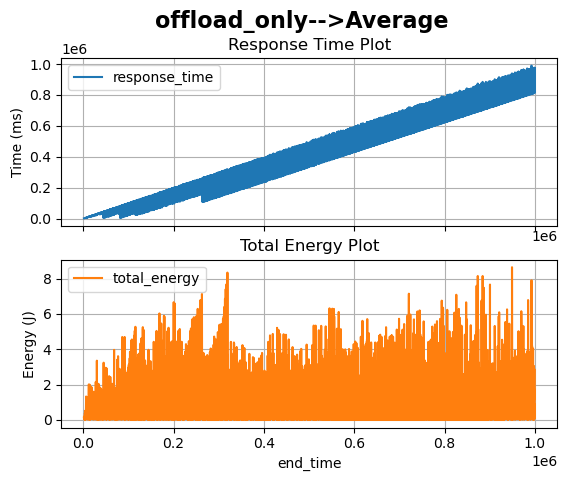

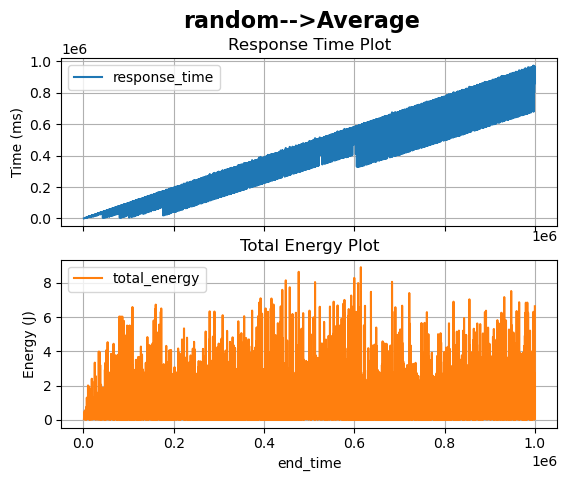

In [8]:
for a in algorithms:
    print("=========================================")
    print(a,"-------AVERAGE----->")
    scrapers[a].calc_average_for_each_end_time(plot=True,plot_title=a+"-->"+"Average")

proposed -------SUM----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1328               1327                127            1200               0.0   
1599               1598                798             800               0.0   
1728               1627                 28             400               0.0   
1952               1951                551            1400               0.0   
2101               2000                  0            2000               0.2   
...                 ...                ...             ...               ...   
999352           943151              15399            1200               0.0   
999728           956727               4573            2000               0.0   
999749           697348                910            1800               0.0   
999757           909156               2080            2000               0.0   
999813        

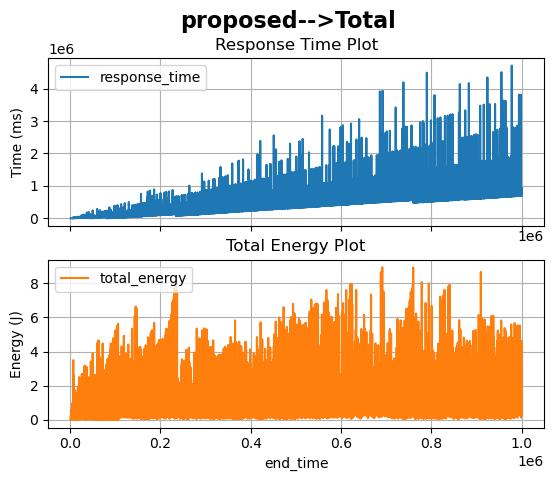

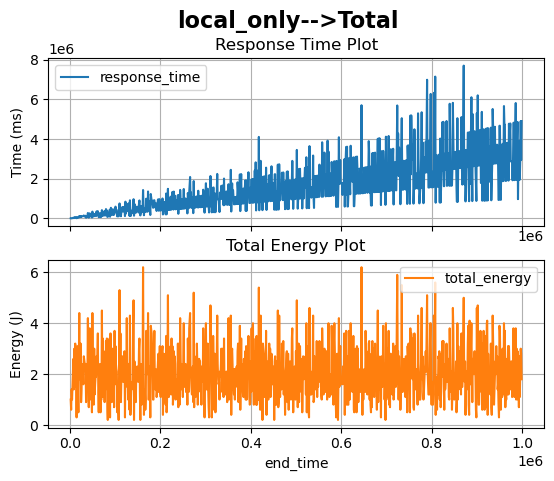

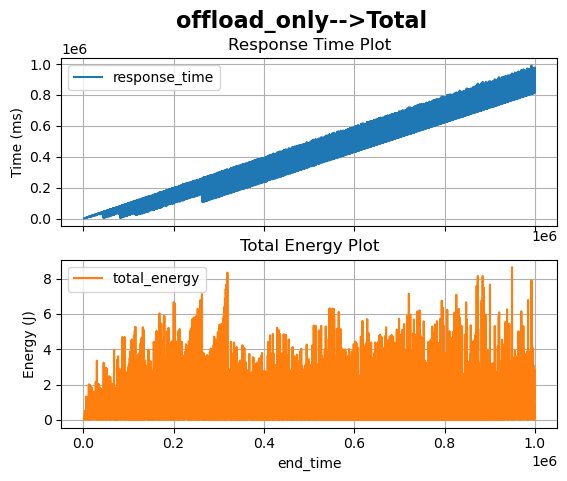

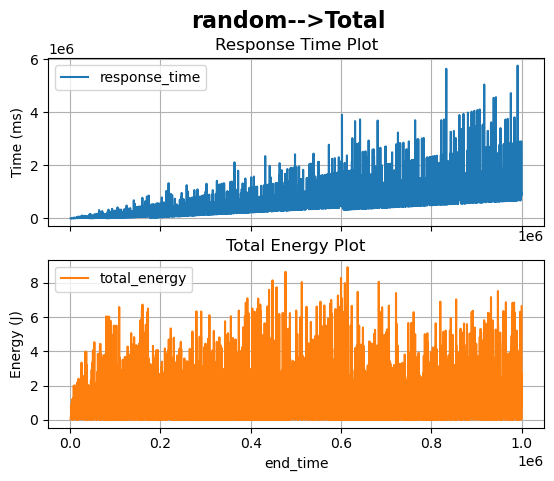

In [9]:
for a in algorithms:
    print("=========================================")
    print(a,"-------SUM----->")
    scrapers[a].calc_sum_for_each_end_time(plot=True,plot_title=a+"-->"+"Total")